In [2]:
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
github_token = secrets.get_secret("github_secret")

github_username = "shaambhavi-dubey"
repo_name = "gnn-upi"
repo_url = f"https://{github_token}@github.com/{github_username}/{repo_name}.git"

!git clone {repo_url}
!cd gnn-upi && git config user.email "25bit087@sot.pdpu.ac.in"
!cd gnn-upi && git config user.name "shaambhavi-dubey"

!pip install torch_geometric --quiet

Cloning into 'gnn-upi'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (70/70), done. (24/70)
remote: Total 81 (delta 35), reused 29 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 614.91 KiB | 8.31 MiB/s, done.
Resolving deltas: 100% (35/35), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00a 0:00:01


In [11]:
import networkx as nx
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, average_precision_score, f1_score
from xgboost import XGBClassifier
from torch_geometric.nn import GCNConv, SAGEConv
import json

Graph "easy"   → run XGBoost tabular → run XGBoost+graphstats → run GCN → run GraphSAGE  (4 results)
Graph "medium" → run XGBoost tabular → run XGBoost+graphstats → run GCN → run GraphSAGE  (4 results)
Graph "hard"   → run XGBoost tabular → run XGBoost+graphstats → run GCN → run GraphSAGE  (4 results)

In [3]:
# finally we are going to create a more complex synthetic graph and see ow the models perform on this new graph, generated ourselves and also labelled 
# we will make 3 new graphs -> easy,medium and hard which basically ranges number of sources and changes the fraud rings and run all 4 onthe 3 graphs
# this is the robustness sweep
def generate_synthetic_graph(n_legit=10000, n_rings=250,
                               sources_range=(15, 40),
                               fraud_amt_range=None,   # None = original tight range; or overlap with legit
                               seed=42):
    random.seed(seed)
    np.random.seed(seed)

    Gr = nx.barabasi_albert_graph(n=n_legit, m=3, seed=seed)
    DirGr = nx.DiGraph()
    DirGr.add_nodes_from(Gr.nodes())
    for u, v in Gr.edges():
        if random.random() < 0.5:
            DirGr.add_edge(u, v)
        else:
            DirGr.add_edge(v, u)

    for u, v in DirGr.edges():
        amount = np.random.lognormal(mean=4, sigma=1.2)
        DirGr[u][v]['amount'] = round(amount, 2)

    account_age_days = {n: random.randint(30, 2000) for n in DirGr.nodes()}
    nx.set_node_attributes(DirGr, account_age_days, 'account_age_days')
    nx.set_node_attributes(DirGr, 0, 'label')

    all_nodes = list(DirGr.nodes())
    random.shuffle(all_nodes)
    mule_nodes = all_nodes[:n_rings]
    remaining_pool = all_nodes[n_rings:]

    for mule in mule_nodes:
        n_sources = random.randint(*sources_range)
        sources = random.sample(remaining_pool, n_sources)

        if fraud_amt_range == "camouflaged":
            # draw fraud amounts from the SAME lognormal distribution as legit transactions
            for src in sources:
                if src == mule:
                    continue
                amt = round(np.random.lognormal(mean=4, sigma=1.2), 2)
                DirGr.add_edge(src, mule, amount=amt)
        else:
            min_amt = random.uniform(5, 20)
            max_amt = min_amt + random.uniform(50, 200)
            for src in sources:
                if src == mule:
                    continue
                amt = round(random.uniform(min_amt, max_amt), 2)
                DirGr.add_edge(src, mule, amount=amt)

        DirGr.nodes[mule]['label'] = 1

    return DirGr


In [5]:
configs = {
    "easy (original)": {"sources_range": (15, 40), "fraud_amt_range": None},
    "medium (smaller rings)": {"sources_range": (8, 20), "fraud_amt_range": None},
    "hard (camouflaged amounts)": {"sources_range": (8, 20), "fraud_amt_range": "camouflaged"},
}

In [6]:
# model functions
def run_xgboost_tabular(graph):
    amt_stat = []
    for n in graph.nodes():
        incoming = [graph[u][n]['amount'] for u in graph.predecessors(n)]
        outgoing = [graph[n][t]['amount'] for t in graph.successors(n)]
        total = incoming + outgoing
        amt_stat.append({
            "node_id": n,
            "avg_amt": sum(total)/len(total) if total else 0,
            "max_amount": max(total) if total else 0,
            "account_age_days": graph.nodes[n]['account_age_days'],
            "label": graph.nodes[n]['label']
        })
    df = pd.DataFrame(amt_stat)
    X = df.drop(columns=["node_id", "label"])
    y = df["label"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    scale = (y_train == 0).sum() / (y_train == 1).sum()
    model = XGBClassifier(n_estimators=200, max_depth=4, scale_pos_weight=scale, eval_metric="aucpr", random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {"f1": f1_score(y_test, y_pred), "pr_auc": average_precision_score(y_test, y_proba)}

In [7]:
def run_xgboost_graphstats(graph):
    in_deg = dict(graph.in_degree())
    out_deg = dict(graph.out_degree())
    pagerank = nx.pagerank(graph, weight='amount')
    amt_stat = []
    for n in graph.nodes():
        incoming = [graph[u][n]['amount'] for u in graph.predecessors(n)]
        outgoing = [graph[n][t]['amount'] for t in graph.successors(n)]
        total = incoming + outgoing
        amt_stat.append({
            "node_id": n,
            "avg_amt": sum(total)/len(total) if total else 0,
            "max_amount": max(total) if total else 0,
            "account_age_days": graph.nodes[n]['account_age_days'],
            "in_degree": in_deg[n],
            "out_degree": out_deg[n],
            "pagerank": pagerank[n],
            "label": graph.nodes[n]['label']
        })
    df = pd.DataFrame(amt_stat)
    X = df.drop(columns=["node_id", "label"])
    y = df["label"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    scale = (y_train == 0).sum() / (y_train == 1).sum()
    model = XGBClassifier(n_estimators=200, max_depth=4, scale_pos_weight=scale, eval_metric="aucpr", random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {"f1": f1_score(y_test, y_pred), "pr_auc": average_precision_score(y_test, y_proba)}

In [8]:
def run_gcn(graph, hidden_channels=64, epochs=300):
    for n in graph.nodes():
        incoming = [graph[u][n]['amount'] for u in graph.predecessors(n)]
        outgoing = [graph[n][t]['amount'] for t in graph.successors(n)]
        total = incoming + outgoing
        graph.nodes[n]['avg_amt'] = sum(total)/len(total) if total else 0.0
        graph.nodes[n]['max_amount'] = float(max(total)) if total else 0.0
        graph.nodes[n]['in_degree'] = graph.in_degree(n)
        graph.nodes[n]['out_degree'] = graph.out_degree(n)

    data = from_networkx(graph, group_node_attrs=['account_age_days', 'avg_amt', 'max_amount', 'in_degree', 'out_degree'])
    data.y = torch.tensor([graph.nodes[n]['label'] for n in graph.nodes()], dtype=torch.long)

    n_nodes = data.num_nodes
    indices = np.arange(n_nodes)
    train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=data.y.numpy(), random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=data.y.numpy()[temp_idx], random_state=42)

    train_mask = torch.zeros(n_nodes, dtype=torch.bool); train_mask[train_idx] = True
    val_mask = torch.zeros(n_nodes, dtype=torch.bool); val_mask[val_idx] = True
    test_mask = torch.zeros(n_nodes, dtype=torch.bool); test_mask[test_idx] = True
    data.train_mask, data.val_mask, data.test_mask = train_mask, val_mask, test_mask

    scaler = StandardScaler()
    data.x = torch.tensor(scaler.fit_transform(data.x.numpy()), dtype=torch.float)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)

    class GCN(nn.Module):
        def __init__(self, in_c, hid_c, out_c):
            super().__init__()
            self.conv1 = GCNConv(in_c, hid_c)
            self.conv2 = GCNConv(hid_c, hid_c)
            self.conv3 = GCNConv(hid_c, out_c)
        def forward(self, x, edge_index):
            x = F.relu(self.conv1(x, edge_index))
            x = F.dropout(x, p=0.5, training=self.training)
            x = F.relu(self.conv2(x, edge_index))
            x = F.dropout(x, p=0.5, training=self.training)
            return self.conv3(x, edge_index)

    model = GCN(data.x.shape[1], hidden_channels, 2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    class_counts = torch.bincount(data.y[data.train_mask])
    class_weights = torch.sqrt((class_counts.sum() / class_counts).float()).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        probs = F.softmax(out, dim=1)[:, 1]

    from sklearn.metrics import precision_recall_curve
    val_probs = probs[data.val_mask].cpu().numpy()
    val_labels = data.y[data.val_mask].cpu().numpy()
    precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
    f1s = 2*(precisions*recalls)/(precisions+recalls+1e-8)
    best_thresh = thresholds[f1s.argmax()]

    test_probs = probs[data.test_mask].cpu().numpy()
    test_labels = data.y[data.test_mask].cpu().numpy()
    test_preds = (test_probs >= best_thresh).astype(int)

    return {"f1": f1_score(test_labels, test_preds), "pr_auc": average_precision_score(test_labels, test_probs)}

In [9]:
def run_graphsage(graph, hidden_channels=64, epochs=300):
    # same feature-building and split as GCN, reused
    for n in graph.nodes():
        incoming = [graph[u][n]['amount'] for u in graph.predecessors(n)]
        outgoing = [graph[n][t]['amount'] for t in graph.successors(n)]
        total = incoming + outgoing
        graph.nodes[n]['avg_amt'] = sum(total)/len(total) if total else 0.0
        graph.nodes[n]['max_amount'] = float(max(total)) if total else 0.0
        graph.nodes[n]['in_degree'] = graph.in_degree(n)
        graph.nodes[n]['out_degree'] = graph.out_degree(n)

    data = from_networkx(graph, group_node_attrs=['account_age_days', 'avg_amt', 'max_amount', 'in_degree', 'out_degree'])
    data.y = torch.tensor([graph.nodes[n]['label'] for n in graph.nodes()], dtype=torch.long)

    n_nodes = data.num_nodes
    indices = np.arange(n_nodes)
    train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=data.y.numpy(), random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=data.y.numpy()[temp_idx], random_state=42)

    train_mask = torch.zeros(n_nodes, dtype=torch.bool); train_mask[train_idx] = True
    val_mask = torch.zeros(n_nodes, dtype=torch.bool); val_mask[val_idx] = True
    test_mask = torch.zeros(n_nodes, dtype=torch.bool); test_mask[test_idx] = True
    data.train_mask, data.val_mask, data.test_mask = train_mask, val_mask, test_mask

    scaler = StandardScaler()
    data.x = torch.tensor(scaler.fit_transform(data.x.numpy()), dtype=torch.float)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)

    class SAGE(nn.Module):
        def __init__(self, in_c, hid_c, out_c):
            super().__init__()
            self.conv1 = SAGEConv(in_c, hid_c)
            self.conv2 = SAGEConv(hid_c, out_c)
        def forward(self, x, edge_index):
            x = F.relu(self.conv1(x, edge_index))
            x = F.dropout(x, p=0.5, training=self.training)
            return self.conv2(x, edge_index)

    model = SAGE(data.x.shape[1], hidden_channels, 2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    class_counts = torch.bincount(data.y[data.train_mask])
    class_weights = torch.sqrt((class_counts.sum() / class_counts).float()).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        probs = F.softmax(out, dim=1)[:, 1]

    from sklearn.metrics import precision_recall_curve
    val_probs = probs[data.val_mask].cpu().numpy()
    val_labels = data.y[data.val_mask].cpu().numpy()
    precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
    f1s = 2*(precisions*recalls)/(precisions+recalls+1e-8)
    best_thresh = thresholds[f1s.argmax()]

    test_probs = probs[data.test_mask].cpu().numpy()
    test_labels = data.y[data.test_mask].cpu().numpy()
    test_preds = (test_probs >= best_thresh).astype(int)

    return {"f1": f1_score(test_labels, test_preds), "pr_auc": average_precision_score(test_labels, test_probs)}

In [13]:
# generates each config's graph, runs all 4 models, collects everything into one results table
sweep_results = []

for config_name, params in configs.items():
    print(f"\n Running config: {config_name}")
    graph = generate_synthetic_graph(
        sources_range=params["sources_range"],
        fraud_amt_range=params["fraud_amt_range"],
        seed=42
    )

    n_fraud = sum(nx.get_node_attributes(graph, 'label').values())
    print(f"Graph built: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges, {n_fraud} fraud")

    print("running XGBoost tabular...")
    r1 = run_xgboost_tabular(graph.copy())

    print("running XGBoost + graphstats...")
    r2 = run_xgboost_graphstats(graph.copy())

    print("unning GCN...")
    r3 = run_gcn(graph.copy())

    print("running GraphSAGE...")
    r4 = run_graphsage(graph.copy())

    sweep_results.append({
        "config": config_name,
        "xgb_tabular_f1": r1["f1"], "xgb_tabular_pr_auc": r1["pr_auc"],
        "xgb_graphstats_f1": r2["f1"], "xgb_graphstats_pr_auc": r2["pr_auc"],
        "gcn_f1": r3["f1"], "gcn_pr_auc": r3["pr_auc"],
        "graphsage_f1": r4["f1"], "graphsage_pr_auc": r4["pr_auc"],
    })

    print(f"Done: {sweep_results[-1]}")

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df)


 Running config: easy (original)
Graph built: 10000 nodes, 36980 edges, 250 fraud
running XGBoost tabular...
running XGBoost + graphstats...
unning GCN...
running GraphSAGE...
Done: {'config': 'easy (original)', 'xgb_tabular_f1': 0.1342281879194631, 'xgb_tabular_pr_auc': np.float64(0.09612952773395837), 'xgb_graphstats_f1': 0.9702970297029703, 'xgb_graphstats_pr_auc': np.float64(0.9945447185325743), 'gcn_f1': 0.958904109589041, 'gcn_pr_auc': np.float64(0.9441427589147264), 'graphsage_f1': 1.0, 'graphsage_pr_auc': np.float64(0.9999999999999999)}

 Running config: medium (smaller rings)
Graph built: 10000 nodes, 33478 edges, 250 fraud
running XGBoost tabular...
running XGBoost + graphstats...
unning GCN...
running GraphSAGE...
Done: {'config': 'medium (smaller rings)', 'xgb_tabular_f1': 0.04411764705882353, 'xgb_tabular_pr_auc': np.float64(0.0476851601503436), 'xgb_graphstats_f1': 0.8490566037735849, 'xgb_graphstats_pr_auc': np.float64(0.9159895051862215), 'gcn_f1': 0.6097560975609756, 

In [17]:
test_graph = generate_synthetic_graph(sources_range=(15,40), fraud_amt_range=None, seed=42)

amt_stat = []
for n in test_graph.nodes():
    incoming = [test_graph[u][n]['amount'] for u in test_graph.predecessors(n)]
    outgoing = [test_graph[n][t]['amount'] for t in test_graph.successors(n)]
    total = incoming + outgoing
    amt_stat.append({
        "node_id": n,
        "avg_amt": sum(total)/len(total) if total else 0,
        "max_amount": max(total) if total else 0,
        "account_age_days": test_graph.nodes[n]['account_age_days'],
        "label": test_graph.nodes[n]['label']
    })
df_check = pd.DataFrame(amt_stat)

X = df_check.drop(columns=["node_id", "label"])
y = df_check["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Train fraud:", y_train.sum(), "Test fraud:", y_test.sum())
print(X_train.describe())
print(X_train[y_train==1].describe())

Train fraud: 200 Test fraud: 50
           avg_amt    max_amount  account_age_days
count  8000.000000   8000.000000       8000.000000
mean    107.326845    320.790040       1018.736125
std      89.437906    412.524896        568.323969
min       3.953333      6.230000         30.000000
25%      59.800625    122.732500        533.000000
50%      86.799224    205.240000       1015.000000
75%     127.316761    375.310000       1513.000000
max    2448.580000  11788.750000       2000.000000
          avg_amt   max_amount  account_age_days
count  200.000000   200.000000        200.000000
mean    82.943478   352.998750       1019.880000
std     25.018689   522.052737        576.287892
min     32.205484    75.260000         50.000000
25%     64.742500   153.805000        572.750000
50%     81.177166   205.905000       1007.500000
75%     98.447917   392.215000       1550.000000
max    209.184792  6072.250000       1993.000000


In [18]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
model_check = XGBClassifier(n_estimators=200, max_depth=4, scale_pos_weight=scale, eval_metric="aucpr", random_state=42)
model_check.fit(X_train, y_train)

importances = pd.Series(model_check.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

y_pred_check = model_check.predict(X_test)
y_proba_check = model_check.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_check))

max_amount          0.391016
avg_amt             0.373628
account_age_days    0.235356
dtype: float32
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1950
           1       0.10      0.20      0.13        50

    accuracy                           0.94      2000
   macro avg       0.54      0.58      0.55      2000
weighted avg       0.96      0.94      0.95      2000



In [19]:
sweep_results_clean = sweep_df.to_dict(orient='records')

results_07 = {
    "notebook": "07_robustness_sweep",
    "configs_tested": list(configs.keys()),
    "results": sweep_results_clean,
    "key_finding": "GraphSAGE most robust across difficulty levels (F1: 1.00 -> 0.83 -> 0.85), outperforming GCN at every level. XGBoost+graphstats also robust to camouflage (relies on structure, not amount) but more sensitive to ring size reduction. XGBoost tabular-only highly unstable, dependent on incidental amount-distribution separation rather than genuine fraud signal."
}

import json
with open("gnn-upi/data/results_07_robustness_sweep.json", "w") as f:
    json.dump(results_07, f, indent=2)

print("saved")

saved


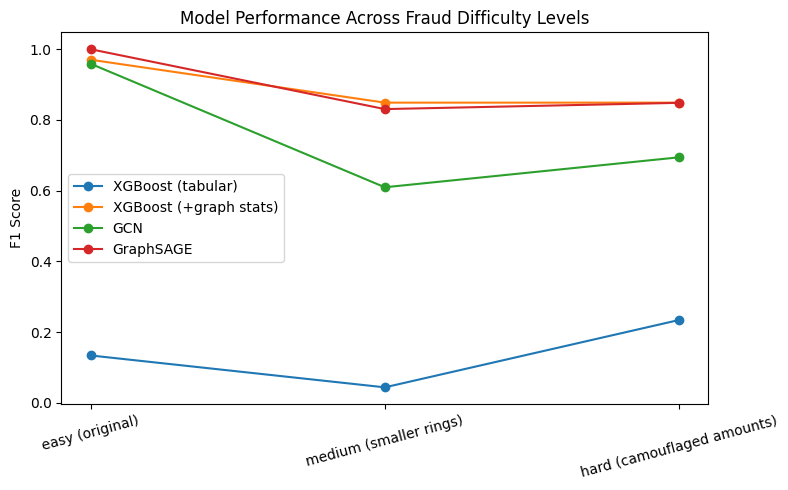

In [20]:
# degradation curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

configs_order = list(configs.keys())
ax.plot(configs_order, sweep_df['xgb_tabular_f1'], marker='o', label='XGBoost (tabular)')
ax.plot(configs_order, sweep_df['xgb_graphstats_f1'], marker='o', label='XGBoost (+graph stats)')
ax.plot(configs_order, sweep_df['gcn_f1'], marker='o', label='GCN')
ax.plot(configs_order, sweep_df['graphsage_f1'], marker='o', label='GraphSAGE')

ax.set_ylabel('F1 Score')
ax.set_title('Model Performance Across Fraud Difficulty Levels')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("gnn-upi/paper/robustness_sweep_f1.png", dpi=150)
plt.show()